In [ ]:
# Importing required libraries
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
ticker = "AAPL"

In [3]:
stock_data = yf.download(ticker, start="2015-01-01", end="2024-12-31", progress=False)

In [4]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.171761,24.638260,23.734002,24.627205,212818400
2015-01-05,23.490803,24.021419,23.305088,23.941826,257142000
2015-01-06,23.493006,23.751680,23.132628,23.554911,263188400
2015-01-07,23.822433,23.921923,23.590288,23.700833,160423600
2015-01-08,24.737749,24.795233,24.032472,24.149651,237458000


In [5]:
stock_data.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-12-23,253.430862,253.808114,251.623968,252.934465,40858800
2024-12-24,256.339752,256.349660,253.450699,253.649270,23234700
2024-12-26,257.153778,258.226014,255.773809,256.329771,27237100
2024-12-27,253.748550,256.836160,251.236779,255.972402,42355300
2024-12-30,250.382965,251.673602,248.943415,250.412748,35557500


In [6]:
stock_data.shape

(2515, 5)

In [7]:
stock_data.to_csv("apple_stock_data.csv")

In [8]:
stock_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2515 entries, 2015-01-02 to 2024-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   2515 non-null   float64
 1   (High, AAPL)    2515 non-null   float64
 2   (Low, AAPL)     2515 non-null   float64
 3   (Open, AAPL)    2515 non-null   float64
 4   (Volume, AAPL)  2515 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 117.9 KB


In [9]:
stock_data.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2515.000000,2515.000000,2515.000000,2515.000000,2.515000e+03
mean,93.542514,94.450779,92.531587,93.455092,1.171162e+08
std,65.203343,65.794112,64.517595,65.121247,6.839222e+07
min,20.548147,20.850664,20.350264,20.470817,2.323470e+07
25%,35.107780,35.510328,34.749594,35.138587,7.108655e+07
50%,64.199005,64.547508,63.392513,63.957959,1.003845e+08
75%,149.811943,151.534893,147.801540,149.594844,1.426222e+08
max,257.153778,258.226014,255.773809,256.329771,6.488252e+08


In [10]:
stock_data.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

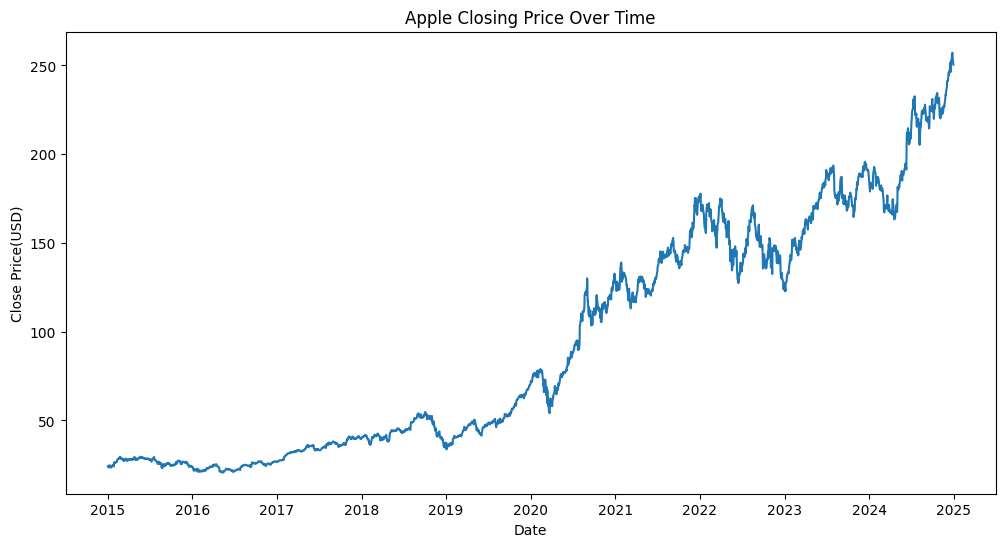

In [ ]:
#Close price plot
plt.figure(figsize=(12,6))

plt.plot(stock_data.index, stock_data['Close'])

plt.title("Apple Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price(USD)")

plt.show()

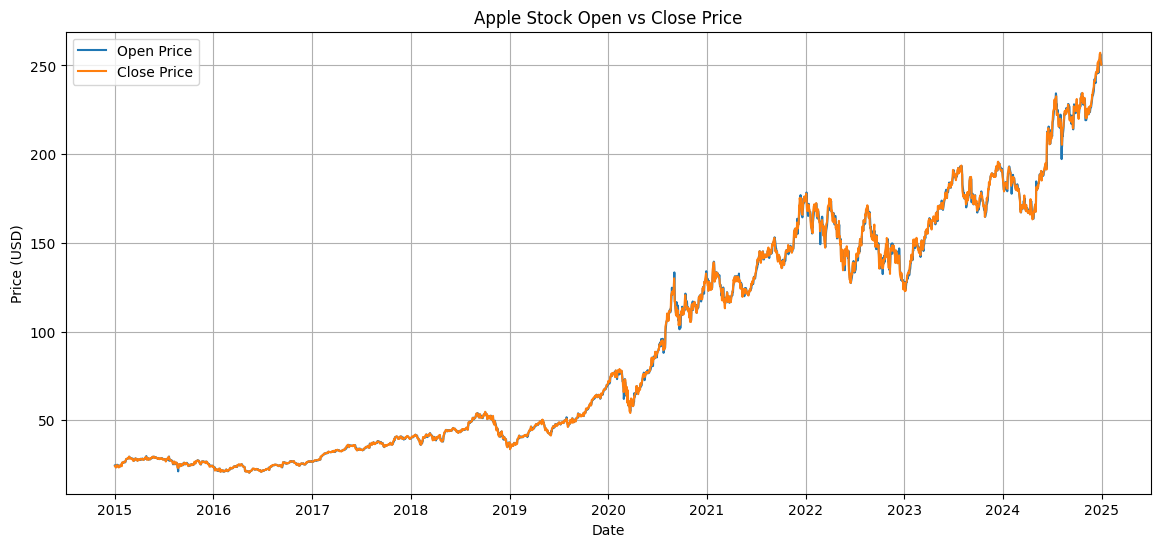

In [12]:

plt.figure(figsize=(14, 6))
plt.plot(stock_data.index, stock_data['Open'], label='Open Price')
plt.plot(stock_data.index, stock_data['Close'], label='Close Price')
plt.title('Apple Stock Open vs Close Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

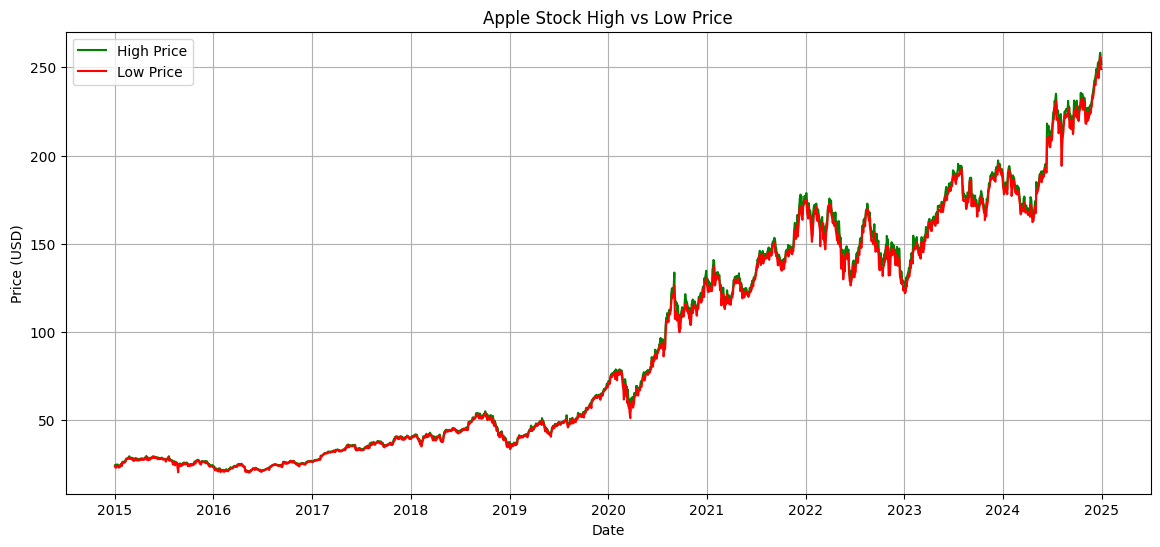

In [13]:
plt.figure(figsize=(14, 6))
plt.plot(stock_data.index, stock_data['High'], label='High Price', color='green')
plt.plot(stock_data.index, stock_data['Low'], label='Low Price', color='red')
plt.title('Apple Stock High vs Low Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

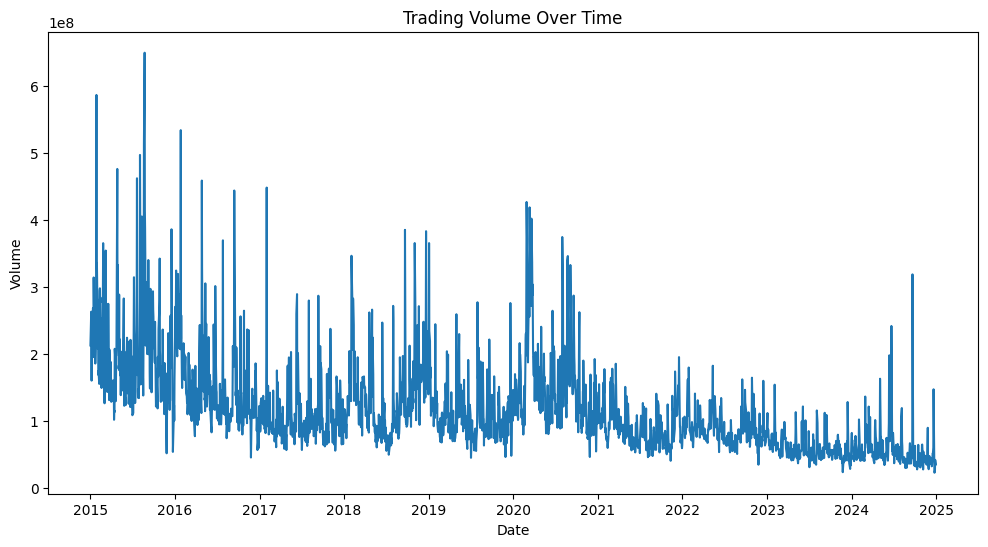

In [14]:
plt.figure(figsize=(12,6))

plt.plot(stock_data.index, stock_data['Volume'])

plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.show()

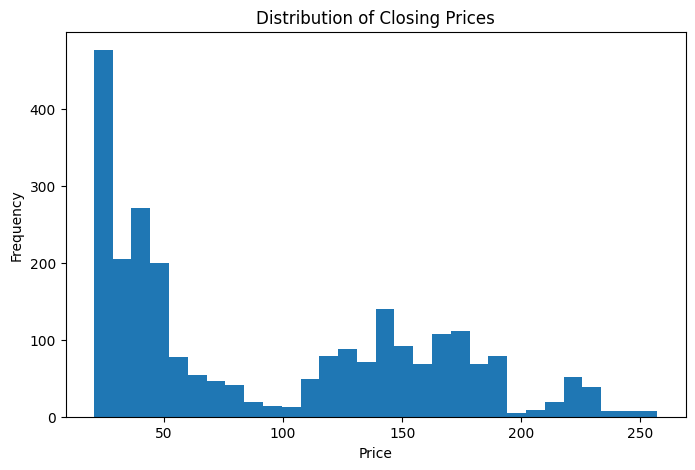

In [15]:
plt.figure(figsize=(8,5))

plt.hist(stock_data['Close'], bins=30)

plt.title("Distribution of Closing Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

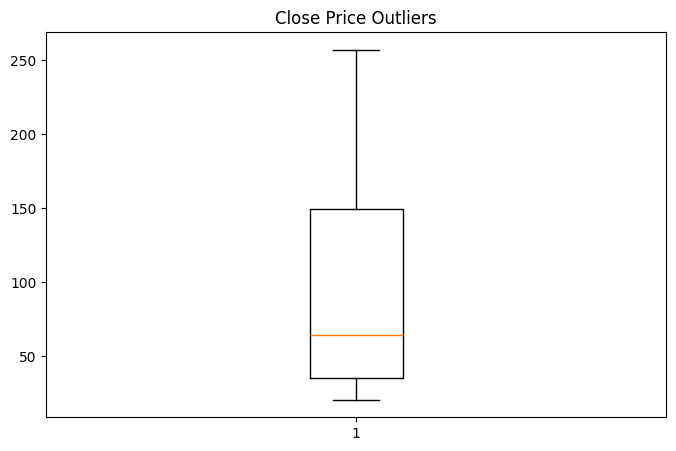

In [16]:
plt.figure(figsize=(8,5))

plt.boxplot(stock_data['Close'])

plt.title("Close Price Outliers")

plt.show()

In [ ]:
# Calculate the daily percentage change in closing price

stock_data['Daily_Return'] = (stock_data['Close'].pct_change())

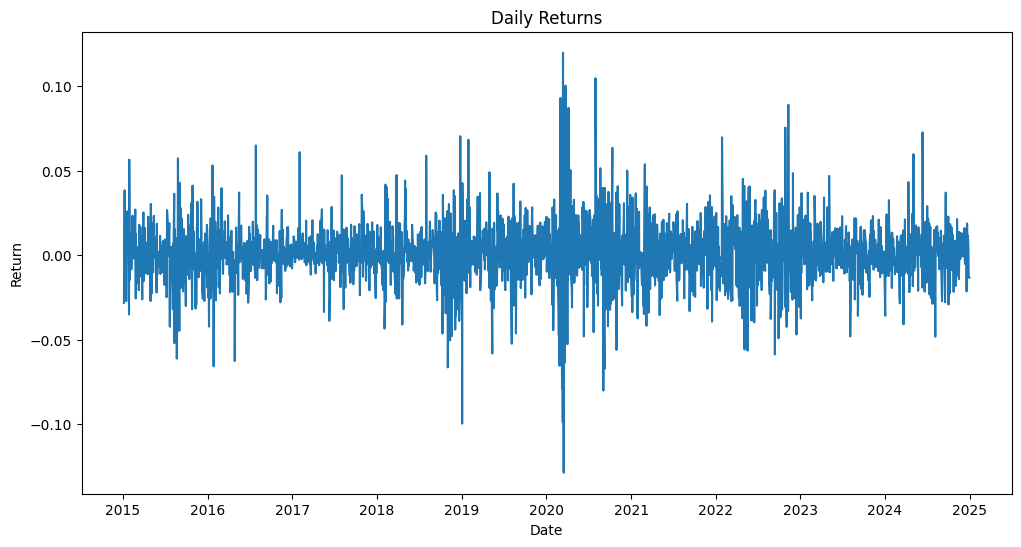

In [18]:
plt.figure(figsize=(12,6))

plt.plot(stock_data.index,stock_data['Daily_Return'])

plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")

plt.show()

In [ ]:
# Calculate the 20-day moving average
stock_data['MA20'] = (stock_data['Close'].rolling(20).mean())
# Calculate the 50-day moving average
stock_data['MA50'] = (stock_data['Close'].rolling(50).mean())

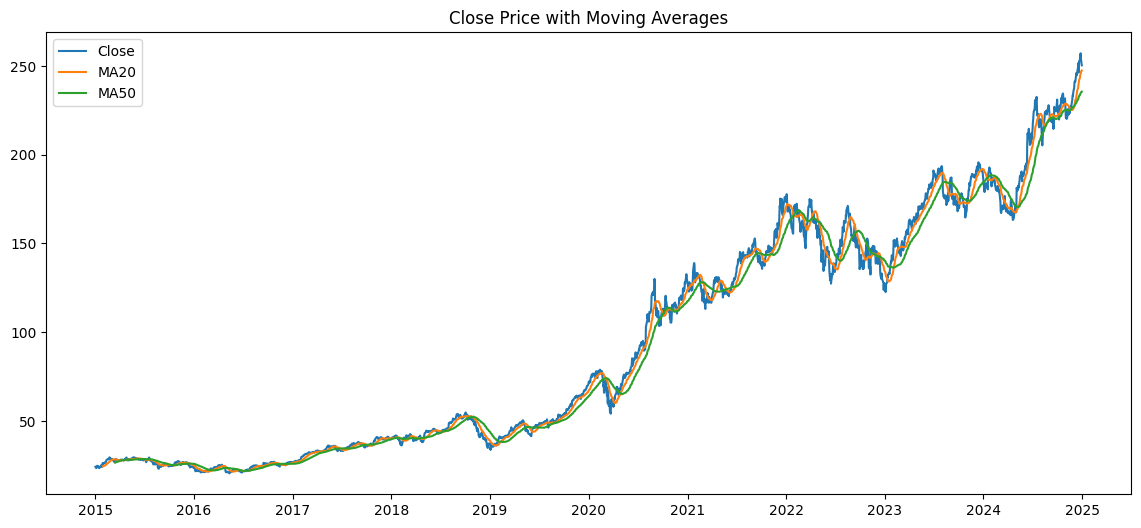

In [20]:
plt.figure(figsize=(14,6))

plt.plot(stock_data.index,stock_data['Close'],label='Close')

plt.plot(stock_data.index, stock_data['MA20'], label='MA20')

plt.plot(stock_data.index, stock_data['MA50'], label='MA50')

plt.legend()
plt.title("Close Price with Moving Averages")

plt.show()

In [21]:
correlation = stock_data[['Open', 'High', 'Low', 'Close', 'Volume']].corr()
print(correlation)

Price              Open      High       Low     Close    Volume
Ticker             AAPL      AAPL      AAPL      AAPL      AAPL
Price  Ticker                                                  
Open   AAPL    1.000000  0.999869  0.999866  0.999714 -0.531667
High   AAPL    0.999869  1.000000  0.999824  0.999867 -0.528643
Low    AAPL    0.999866  0.999824  1.000000  0.999866 -0.535199
Close  AAPL    0.999714  0.999867  0.999866  1.000000 -0.532148
Volume AAPL   -0.531667 -0.528643 -0.535199 -0.532148  1.000000


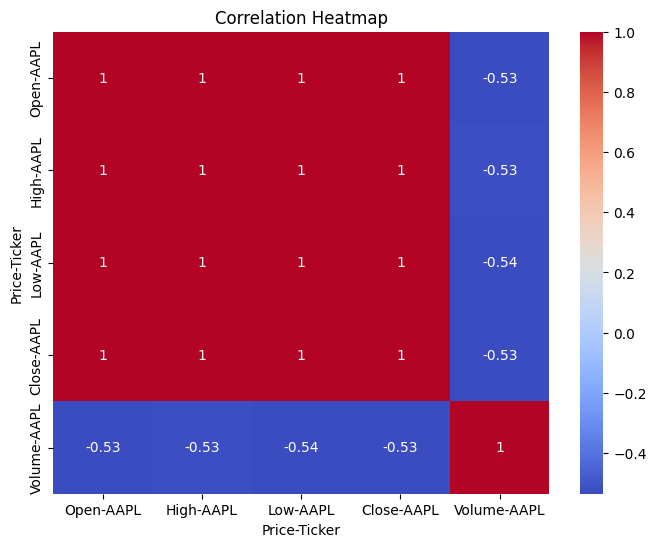

In [22]:

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [23]:
stock_data.isnull().sum()

Price         Ticker
Close         AAPL       0
High          AAPL       0
Low           AAPL       0
Open          AAPL       0
Volume        AAPL       0
Daily_Return             1
MA20                    19
MA50                    49
dtype: int64

In [ ]:
# Create the target as the next day's closing price
stock_data['Target'] = stock_data['Close'].shift(-1)
stock_data.tail()

Price,Close,High,Low,Open,Volume,Daily_Return,MA20,MA50,Target
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,
Date,,,,,,,,,
2024-12-23,253.430862,253.808114,251.623968,252.934465,40858800,0.003065,243.261649,233.584802,256.339752
2024-12-24,256.339752,256.349660,253.450699,253.649270,23234700,0.011478,244.519025,234.123973,257.153778
2024-12-26,257.153778,258.226014,255.773809,256.329771,27237100,0.003176,245.708392,234.628848,253.748550
2024-12-27,253.748550,256.836160,251.236779,255.972402,42355300,-0.013242,246.733950,235.106675,250.382965
2024-12-30,250.382965,251.673602,248.943415,250.412748,35557500,-0.013263,247.472092,235.509852,NaN


In [25]:
stock_data = stock_data.dropna()
print("Final shape:", stock_data.shape)

Final shape: (2465, 9)


In [26]:
stock_data.tail()

Price,Close,High,Low,Open,Volume,Daily_Return,MA20,MA50,Target
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,
Date,,,,,,,,,
2024-12-20,252.656494,253.162814,243.919892,246.252952,147495300,0.018816,242.000798,233.029430,253.430862
2024-12-23,253.430862,253.808114,251.623968,252.934465,40858800,0.003065,243.261649,233.584802,256.339752
2024-12-24,256.339752,256.349660,253.450699,253.649270,23234700,0.011478,244.519025,234.123973,257.153778
2024-12-26,257.153778,258.226014,255.773809,256.329771,27237100,0.003176,245.708392,234.628848,253.748550
2024-12-27,253.748550,256.836160,251.236779,255.972402,42355300,-0.013242,246.733950,235.106675,250.382965


In [ ]:
# Remove extra column levels and keep the main column names
stock_data.columns = stock_data.columns.get_level_values(0)
# Reset the index and make it a normal column
stock_data = stock_data.reset_index()


In [28]:
stock_data.head()

Price,Date,Close,High,Low,Open,Volume,Daily_Return,MA20,MA50,Target
0,2015-03-16,27.734205,27.734205,27.272525,27.496706,143497200,0.011004,28.347044,26.514826,28.198105
1,2015-03-17,28.198105,28.260254,27.889577,27.945068,204092400,0.016727,28.338276,26.595352,28.515516
2,2015-03-18,28.515516,28.668671,28.049395,28.189231,261083600,0.011256,28.335502,26.695847,28.300205
3,2015-03-19,28.300205,28.688639,28.278009,28.577658,183238000,-0.007551,28.324959,26.791991,27.945076
4,2015-03-20,27.945076,28.499980,27.780824,28.466687,274780400,-0.012549,28.285005,26.874444,28.235846


In [29]:
stock_data.to_csv('aapl_cleaned.csv')

In [30]:
stock_data

Price,Date,Close,High,Low,Open,Volume,Daily_Return,MA20,MA50,Target
0,2015-03-16,27.734205,27.734205,27.272525,27.496706,143497200,0.011004,28.347044,26.514826,28.198105
1,2015-03-17,28.198105,28.260254,27.889577,27.945068,204092400,0.016727,28.338276,26.595352,28.515516
2,2015-03-18,28.515516,28.668671,28.049395,28.189231,261083600,0.011256,28.335502,26.695847,28.300205
3,2015-03-19,28.300205,28.688639,28.278009,28.577658,183238000,-0.007551,28.324959,26.791991,27.945076
4,2015-03-20,27.945076,28.499980,27.780824,28.466687,274780400,-0.012549,28.285005,26.874444,28.235846
...,...,...,...,...,...,...,...,...,...,...
2460,2024-12-20,252.656494,253.162814,243.919892,246.252952,147495300,0.018816,242.000798,233.029430,253.430862
2461,2024-12-23,253.430862,253.808114,251.623968,252.934465,40858800,0.003065,243.261649,233.584802,256.339752
2462,2024-12-24,256.339752,256.349660,253.450699,253.649270,23234700,0.011478,244.519025,234.123973,257.153778
2463,2024-12-26,257.153778,258.226014,255.773809,256.329771,27237100,0.003176,245.708392,234.628848,253.748550
